In [1]:
import json
import pandas as pd
from PIL import Image
import os

# Извлекаю аннотации из json-файла
with open('output/all_results.json', 'r', encoding='utf-8') as f:
    json_data = json.load(f)['results']


def parse_anns(ann):
    # В данных есть артефакты, поэтому через исключения
    try:
        ann_str = ann.replace('```json\n', '').replace('\n```', '')
        return json.loads(ann_str)
    except:
        return None

output_df_f = 'output/annotaions_with_imgs.pkl'

# Выполняю компоновку датафрейма или загружаю из файла
if os.path.exists(output_df_f):
    df = pd.read_pickle(output_df_f)
else:
    annotations = []
    for f_name, ann in json_data.items():
        if ann['status'] == 'success':
            f_ann = parse_anns(ann['prediction'])
            if f_ann:
                img_path = os.path.join('data/img/', f_name)
                if os.path.exists(img_path):
                    img = Image.open(img_path)
                    annotations.append({
                        'photo_id': f_name,
                        'type': f_ann.get('building_type'),
                        'type_alt': f_ann.get('alternate_building_type'),
                        'age': f_ann.get('building_age'),
                        'surface_mat': f_ann.get('surface_material'),
                        'surface_mat_alt': f_ann.get('alternate_surface_material'),
                        'constr_mat': f_ann.get('construction_material'),
                        'constr_mat_alt': f_ann.get('alternate_construction_material'),
                        'floors': f_ann.get('floors'),
                        'image': img,
                        'img_width': img.width,
                        'img_height': img.height,
                        'wh_ratio': round(img.width / img.height, 2)
                    })
    df = pd.DataFrame(annotations)
    df[['age', 'floors']] = df[['age', 'floors']].astype(int)
    df.to_pickle(output_df_f)
    
df.head(5)

,photo_id,type,type_alt,age,surface_mat,surface_mat_alt,constr_mat,constr_mat_alt,floors,image,img_width,img_height,wh_ratio
0,1093881547883011_740121.jpg,office,education,2023,glass,metal,steel,concrete,5,<PIL.JpegImagePlugin.JpegImageFile image mode=...,739,574,1.29
1,1007001623840957_740923.jpg,office,retail,1910,stone,plaster,stone,brick,4,<PIL.JpegImagePlugin.JpegImageFile image mode=...,707,884,0.80
2,1005857766484927_748849.jpg,industrial,retail,1980,metal,concrete,steel,concrete,2,<PIL.JpegImagePlugin.JpegImageFile image mode=...,1161,520,2.23
3,1101331527302990_879030.jpg,industrial,office,1970,brick,glass,steel,concrete,3,<PIL.JpegImagePlugin.JpegImageFile image mode=...,909,413,2.20
4,1194265617681155_752741.jpg,industrial,office,1990,metal,concrete,steel,concrete,2,<PIL.JpegImagePlugin.JpegImageFile image mode=...,891,392,2.27


In [ ]:
df.iloc[0]['image'].show()

In [ ]:
df.info()

In [ ]:
df.shape

(16921, 13)

In [5]:
# Пропусков не будет, тк они все отвалились при разборе json'а
print(df.isnull().sum())

photo_id           0
type               0
type_alt           0
age                0
surface_mat        0
surface_mat_alt    0
constr_mat         0
constr_mat_alt     0
floors             0
image              0
img_width          0
img_height         0
wh_ratio           0
dtype: int64


In [6]:
# Уникальные типы для моего датасета
print(f"Типы зданий: \n{list(df['type'].unique())};\n\nАльтернативные варианты: \n{list(df['type_alt'].unique())}.")

Типы зданий: 
['office', 'industrial', 'public', 'house', 'apartments', 'retail', 'garage', 'hotel', 'religious', 'education'];

Альтернативные варианты: 
['education', 'retail', 'office', 'industrial', 'apartments', 'garage', 'public', 'hotel', 'house', 'religious', 'stone'].


Text(0.5, 1.0, 'Альтернативные типы зданий')

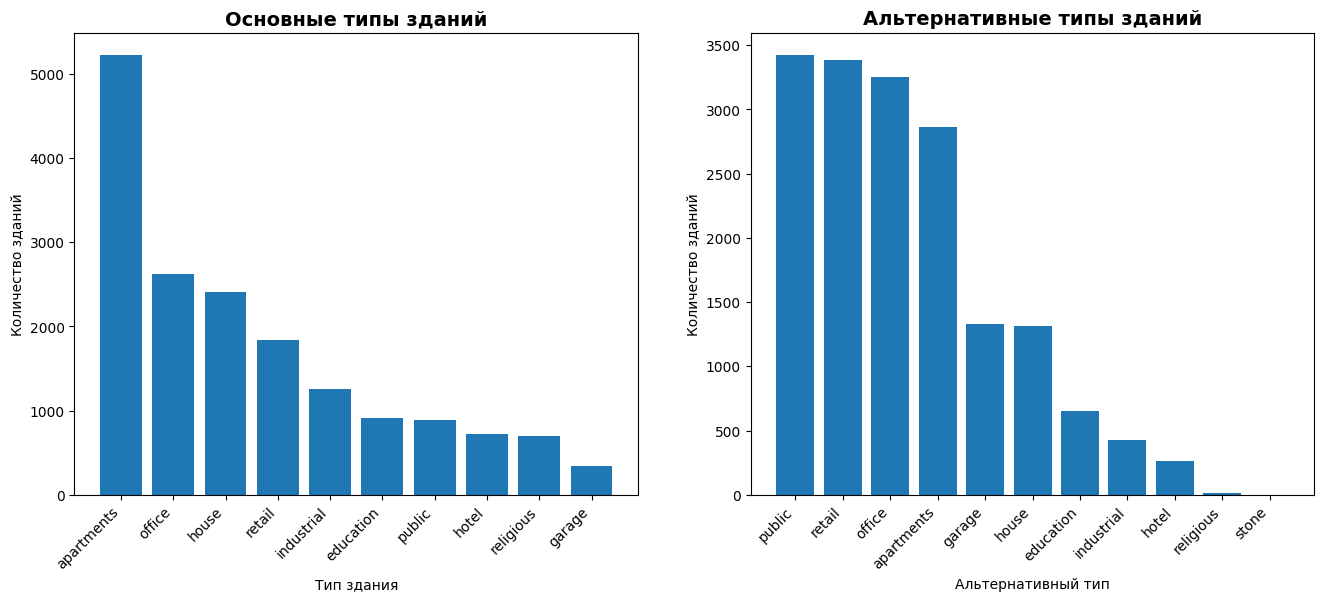

In [7]:
import matplotlib.pyplot as plt

# Распределение по типам зданий
type_cnt = df['type'].value_counts()
type_cnt_alt = df['type_alt'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.bar(range(len(type_cnt)), type_cnt.values)
ax1.set_xticks(range(len(type_cnt)))
ax1.set_xticklabels(type_cnt.index, rotation=45, ha='right')
ax1.set_xlabel('Тип здания')
ax1.set_ylabel('Количество зданий')
ax1.set_title('Основные типы зданий', fontsize=14, fontweight='bold')

ax2.bar(range(len(type_cnt_alt)), type_cnt_alt.values)
ax2.set_xticks(range(len(type_cnt_alt)))
ax2.set_xticklabels(type_cnt_alt.index, rotation=45, ha='right')
ax2.set_xlabel('Альтернативный тип')
ax2.set_ylabel('Количество зданий')
ax2.set_title('Альтернативные типы зданий', fontsize=14, fontweight='bold')

Text(0.5, 1.0, 'Альтернативные материалы конструкции')

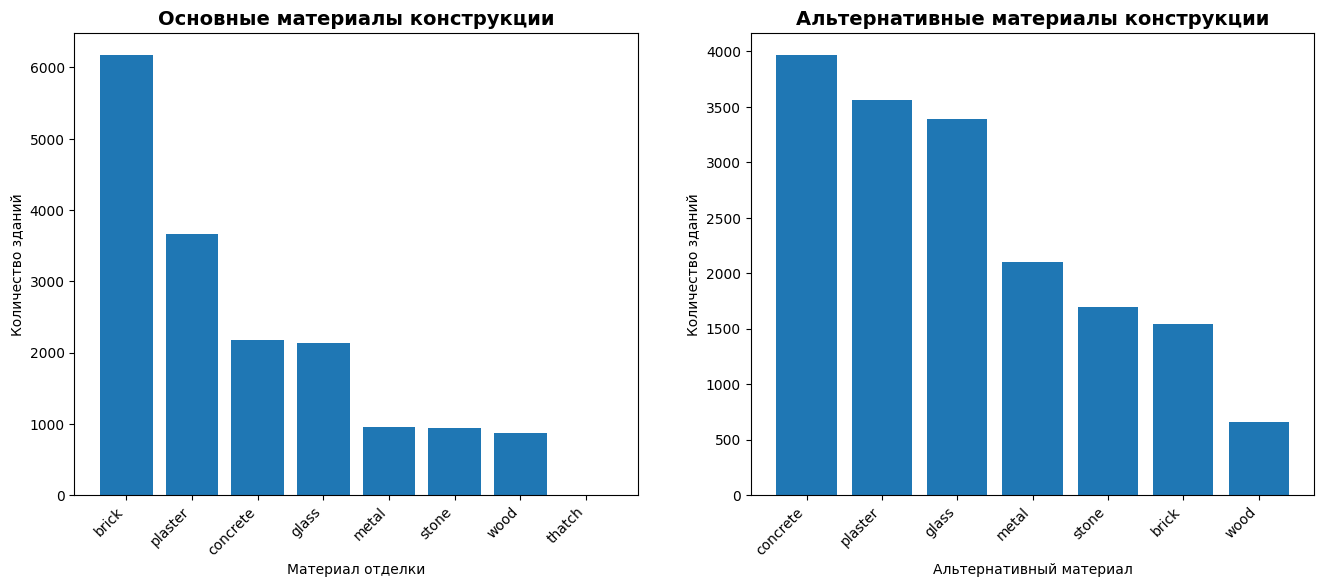

In [8]:
# Распределение по материалам наружней отделки
mat_cnt = df['surface_mat'].value_counts()
mat_cnt_alt = df['surface_mat_alt'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.bar(range(len(mat_cnt)), mat_cnt.values)
ax1.set_xticks(range(len(mat_cnt)))
ax1.set_xticklabels(mat_cnt.index, rotation=45, ha='right')
ax1.set_xlabel('Материал отделки')
ax1.set_ylabel('Количество зданий')
ax1.set_title('Основные материалы конструкции', fontsize=14, fontweight='bold')

ax2.bar(range(len(mat_cnt_alt)), mat_cnt_alt.values)
ax2.set_xticks(range(len(mat_cnt_alt)))
ax2.set_xticklabels(mat_cnt_alt.index, rotation=45, ha='right')
ax2.set_xlabel('Альтернативный материал')
ax2.set_ylabel('Количество зданий')
ax2.set_title('Альтернативные материалы конструкции', fontsize=14, fontweight='bold')

In [9]:
# Посмотрю какая этажность наблюдается в датасете
df['floors'].unique()

array([  5,   4,   2,   3,   7,   6,   1,   8,  10,  15,  12,  18,  21,
        35,  25,   9,  46,  30,  20,  38,  14,  16,  22,  36,  61,  58,
        43,  24,  32,  23,  48,  11, 200,  40,  55,  50,  17,  26,  33,
        31,  29, 100,  56])

**Значения 100 и 200 этажей вполне могут быть артефактами. В ближайшие дни проведу ручную проверку/разметку датасета и посмотрю фото этих зданий.**

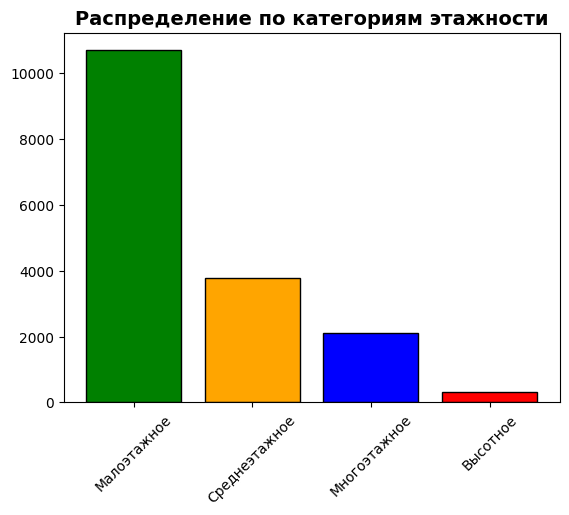

In [10]:
# Оценка категорий в соотвествии с классификации этажности в РФ
def floor_cat(floors):
    if floors <= 4:
        return 'Малоэтажное'
    elif floors > 4 and floors <= 8:
        return 'Среднеэтажное'
    elif floors > 8 and floors <= 25:
        return 'Многоэтажное'
    else:
        return 'Высотное'

df['floor_cat'] = df['floors'].apply(floor_cat)
cat_counts = df['floor_cat'].value_counts()
colors = ['green', 'orange', 'blue', 'red']
plt.bar(cat_counts.index, cat_counts.values, color=colors, edgecolor='black')
plt.title('Распределение по категориям этажности', fontsize=14, fontweight='bold')
plt.tick_params(axis='x', rotation=45)

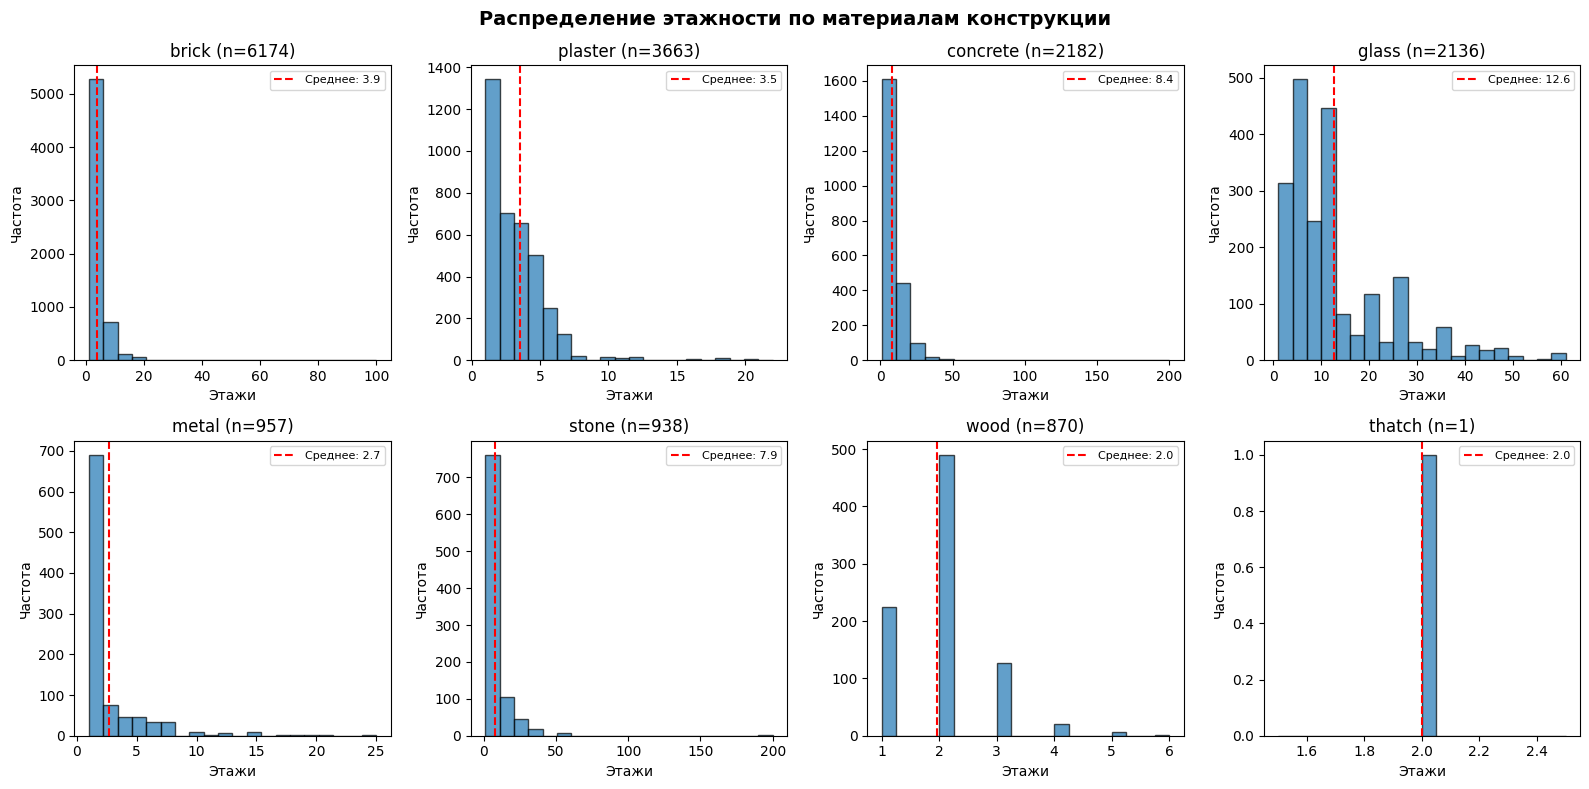

In [11]:
# Распределение этажности для разных материалов конструкции
mats = df['surface_mat'].value_counts().index

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, mat in enumerate(mats):
    subset = df[df['surface_mat'] == mat]['floors']
    axes[i].hist(subset, bins=20, edgecolor='black', alpha=0.7)
    axes[i].axvline(subset.mean(), color='red', ls='--', label=f'Среднее: {subset.mean():.1f}')
    axes[i].set_title(f'{mat} (n={len(subset)})')
    axes[i].set_xlabel('Этажи')
    axes[i].set_ylabel('Частота')
    axes[i].legend(fontsize=8)

plt.suptitle('Распределение этажности по материалам конструкции', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Топ-10 типов зданий по средней этажности')

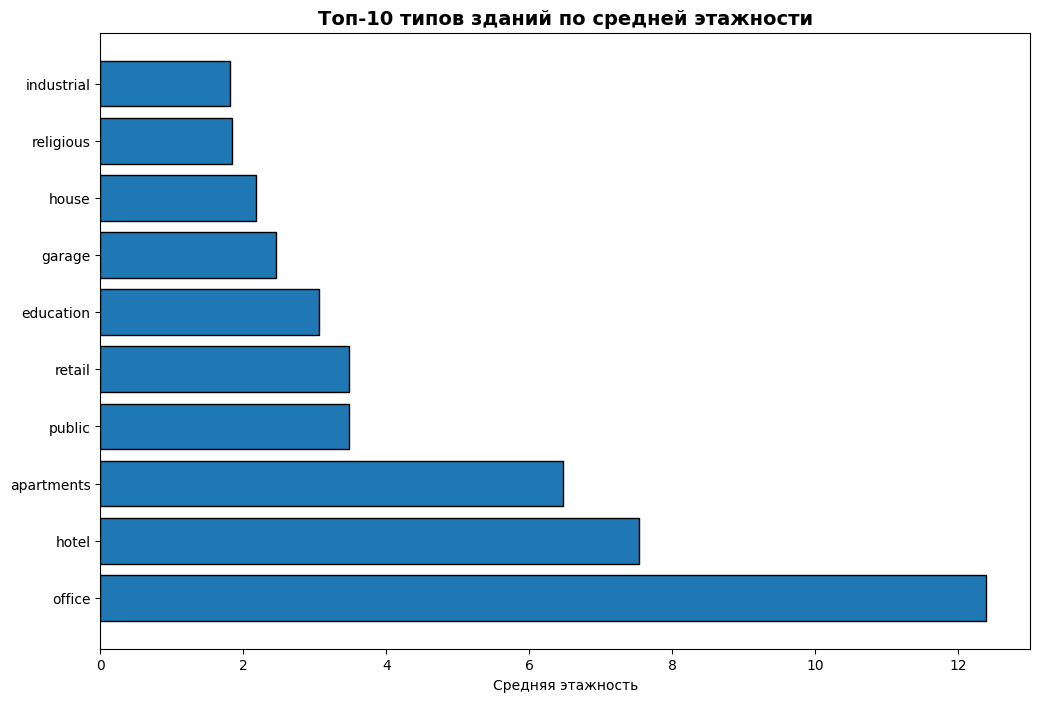

In [12]:
# Средняя этажность в зависимости от типа здания
mean_floors_by_type = df.groupby('type')['floors'].agg(['mean', 'count', 'std']).round(2)
mean_floors_by_type = mean_floors_by_type.sort_values('mean', ascending=False).head(10)

plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(mean_floors_by_type)), mean_floors_by_type['mean'].values, edgecolor='black')
plt.yticks(range(len(mean_floors_by_type)), mean_floors_by_type.index)
plt.xlabel('Средняя этажность')
plt.title('Топ-10 типов зданий по средней этажности', fontsize=14, fontweight='bold')

Text(0.5, 1.0, 'Форматы изображений')

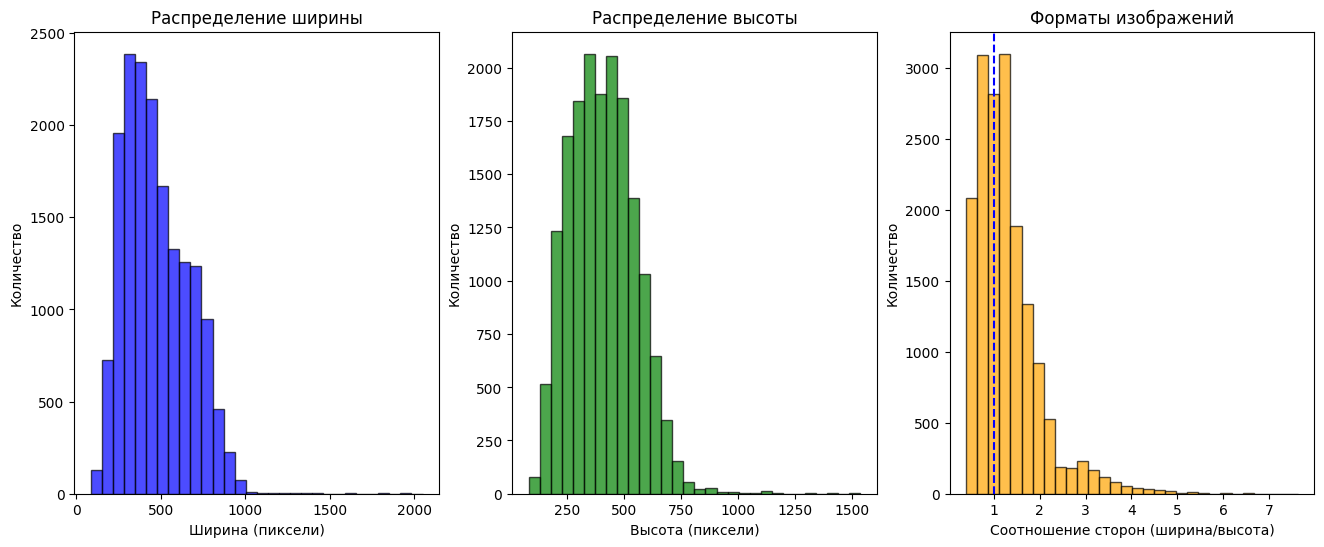

In [13]:
# Параметры размера самих изображений
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))

ax1.hist(df['img_width'], bins=30, edgecolor='black', alpha=0.7, color='blue')
ax1.set_xlabel('Ширина (пиксели)')
ax1.set_ylabel('Количество')
ax1.set_title('Распределение ширины')

ax2.hist(df['img_height'], bins=30, edgecolor='black', alpha=0.7, color='green')
ax2.set_xlabel('Высота (пиксели)')
ax2.set_ylabel('Количество')
ax2.set_title('Распределение высоты')

ax3.hist(df['wh_ratio'], bins=30, edgecolor='black', alpha=0.7, color='orange')
ax3.axvline(1.0, color='blue', ls='--')
ax3.set_xlabel('Соотношение сторон (ширина/высота)')
ax3.set_ylabel('Количество')
ax3.set_title('Форматы изображений')